# Credit Card Customer Segmentation: Exploratory Data Analysis and K-Means Clustering

**Course context:** Final statistics project — Kaggle *Credit Card Dataset for Clustering* (`CC GENERAL.csv`)

**Role in the project:** This notebook covers (1) Exploratory Data Analysis (EDA) and (2) an exploratory customer segmentation using K-means clustering.

**Important note:** This is a statistics course. We have studied descriptive statistics, distributions, confidence intervals, hypothesis testing, correlation, and basic regression, but we have **not** studied clustering in class. For this reason, clustering is presented here as an *exploratory extension* of the statistical analysis, not as a machine-learning project. Every step is explained and justified in plain, academic English.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 20)

np.random.seed(123)


## 1. Dataset Loading and Overview

### Question / Goal
What does this dataset contain, and what does each row represent?

### Method
We load the CSV file and inspect its size, variable names, and data types before doing any analysis.

In [15]:
df = pd.read_csv("CC_GENERAL.csv")

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print()
print("Column names:")
print(df.columns.tolist())


Number of rows: 8950
Number of columns: 18

Column names:
['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


In [16]:
df.head()


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [17]:
df.dtypes


CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

### Interpretation

The dataset contains **8,950 customers** (rows) and **18 variables** (columns). Each row represents one credit card customer, and the variables describe six months of that customer's card usage: balance, purchase behavior (total, one-off, and installment purchases), cash-advance behavior, credit limit, payments, and account tenure.

`CUST_ID` is a text identifier used only to label each customer. It carries no numerical meaning, so it must **not** be used as a feature in any statistical calculation, correlation, or clustering step. We keep it in the data frame for now (rather than deleting it) because we will need it later to relate cluster assignments back to individual customers.

## 2. Data Quality and Cleaning

### Question / Goal
Are there missing values, duplicate rows, or suspicious values that need to be addressed before analysis?

### Method
We check missing values column by column, check for duplicate rows, and look at basic ranges to flag impossible values (e.g., negative balances).

In [18]:
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
print("Missing-value summary (columns with at least one missing value):")
missing_summary


Missing-value summary (columns with at least one missing value):


,missing_count,missing_pct
CREDIT_LIMIT,1,0.01
MINIMUM_PAYMENTS,313,3.50


In [19]:
print("Number of fully duplicated rows:", df.duplicated().sum())
print("Number of duplicated CUST_ID values:", df["CUST_ID"].duplicated().sum())


Number of fully duplicated rows: 0
Number of duplicated CUST_ID values: 0


In [20]:
ranges = df.drop(columns=["CUST_ID"]).agg(["min", "max"]).T
print("Minimum and maximum of every numerical variable (checking for impossible values):")
ranges


Minimum and maximum of every numerical variable (checking for impossible values):


,min,max
BALANCE,0.000000,19043.13856
BALANCE_FREQUENCY,0.000000,1.00000
PURCHASES,0.000000,49039.57000
ONEOFF_PURCHASES,0.000000,40761.25000
INSTALLMENTS_PURCHASES,0.000000,22500.00000
CASH_ADVANCE,0.000000,47137.21176
PURCHASES_FREQUENCY,0.000000,1.00000
ONEOFF_PURCHASES_FREQUENCY,0.000000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,0.000000,1.00000
CASH_ADVANCE_FREQUENCY,0.000000,1.50000


### Interpretation

Only two variables contain missing values: **`CREDIT_LIMIT`** (1 missing value out of 8,950, 0.01%) and **`MINIMUM_PAYMENTS`** (313 missing values, 3.50%). There are no duplicated rows and no duplicated customer IDs, so no rows need to be removed for that reason.

None of the minimum/maximum values look impossible (no negative balances, no negative purchases, no frequency values below 0 or clearly out of range for a proportion-like variable). This means we do not have evidence of data-entry errors — the extreme values we will see later are *statistical outliers*, not *incorrect observations*.

**Cleaning decisions:**
- `MINIMUM_PAYMENTS` is **not** used in the EDA-focus variables or in the clustering variable set chosen in Section 9, so its missing values do not need to be imputed or removed here — dropping those rows automatically would only discard useful information for no benefit.
- `CREDIT_LIMIT` **is** one of the clustering variables, so the single row with a missing value will be excluded specifically when we build the clustering dataset in Section 10, not from the whole dataset.

We now check for potential outliers in the variables most relevant for this analysis, using boxplots and the IQR rule, without removing any observations at this stage.

In [21]:
focus_vars = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT",
              "PAYMENTS", "PURCHASES_FREQUENCY", "CASH_ADVANCE_FREQUENCY", "PRC_FULL_PAYMENT"]

outlier_summary = []
for col in focus_vars:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper_fence = q3 + 1.5 * iqr
    n_outliers = (df[col] > upper_fence).sum()
    outlier_summary.append({
        "variable": col,
        "IQR_upper_fence": round(upper_fence, 2),
        "n_above_fence": n_outliers,
        "pct_above_fence": round(n_outliers / len(df) * 100, 2)
    })

outlier_table = pd.DataFrame(outlier_summary).set_index("variable")
outlier_table


,IQR_upper_fence,n_above_fence,pct_above_fence
variable,,,
BALANCE,4942.93,695,7.77
PURCHASES,2715.87,808,9.03
CASH_ADVANCE,2784.55,1030,11.51
CREDIT_LIMIT,13850.00,248,2.77
PAYMENTS,4177.92,808,9.03
PURCHASES_FREQUENCY,2.17,0,0.00
CASH_ADVANCE_FREQUENCY,0.56,525,5.87
PRC_FULL_PAYMENT,0.36,1474,16.47


### Interpretation

Between roughly 6% and 18% of customers fall above the IQR upper fence for these variables (the exact percentage varies by variable). This is expected for financial behavior data: a small group of customers spend, borrow, or carry balances far above the typical customer. **We do not remove these observations.** A customer with a very high balance or a very large cash advance is not necessarily a data-entry mistake — it may represent a real, important type of customer (for example, someone who relies heavily on credit). Removing them would bias the analysis toward "average" customers and would specifically hide the kind of heterogeneous behavior that motivates clustering in Section 8. We therefore keep all outliers and treat them as real, informative data points.

## 3. Exploratory Data Analysis

### Question / Goal
What are the basic statistical properties (center, spread, and range) of the customer behavior variables that matter most for this project?

### Method
We build a custom descriptive statistics table (not just `.describe()`) for eight key variables that describe balance, spending, cash-advance use, credit capacity, and repayment behavior.

In [22]:
def custom_summary(data, cols):
    rows = []
    for c in cols:
        s = data[c]
        rows.append({
            "variable": c,
            "n": s.count(),
            "missing": s.isna().sum(),
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "Q1": s.quantile(0.25),
            "Q3": s.quantile(0.75),
            "min": s.min(),
            "max": s.max(),
        })
    return pd.DataFrame(rows).set_index("variable").round(2)

descriptive_table = custom_summary(df, focus_vars)
descriptive_table


,n,missing,mean,median,std,Q1,Q3,min,max
variable,,,,,,,,,
BALANCE,8950,0,1564.47,873.39,2081.53,128.28,2054.14,0.0,19043.14
PURCHASES,8950,0,1003.20,361.28,2136.63,39.64,1110.13,0.0,49039.57
CASH_ADVANCE,8950,0,978.87,0.00,2097.16,0.00,1113.82,0.0,47137.21
CREDIT_LIMIT,8949,1,4494.45,3000.00,3638.82,1600.00,6500.00,50.0,30000.00
PAYMENTS,8950,0,1733.14,856.90,2895.06,383.28,1901.13,0.0,50721.48
PURCHASES_FREQUENCY,8950,0,0.49,0.50,0.40,0.08,0.92,0.0,1.00
CASH_ADVANCE_FREQUENCY,8950,0,0.14,0.00,0.20,0.00,0.22,0.0,1.50
PRC_FULL_PAYMENT,8950,0,0.15,0.00,0.29,0.00,0.14,0.0,1.00


### Interpretation

Several patterns stand out immediately:

- For **`BALANCE`**, **`PURCHASES`**, **`CASH_ADVANCE`**, and **`PAYMENTS`**, the mean is noticeably larger than the median (for example, mean `PURCHASES` ≈ 1,003 vs. median ≈ 361; mean `CASH_ADVANCE` ≈ 979 vs. median = 0). This gap between mean and median is a first sign of **right-skewed distributions**: most customers have low-to-moderate values, while a smaller group of customers with very high values pulls the mean upward.
- **`CASH_ADVANCE_FREQUENCY`** and **`PRC_FULL_PAYMENT`** have medians of 0, meaning that more than half of customers essentially never take cash advances and never pay their balance in full — behavior is concentrated near zero for a large share of the customer base.
- **`PURCHASES_FREQUENCY`** is the one variable whose mean (0.49) and median (0.50) are almost identical, suggesting this variable is much closer to symmetric than the others.

We check these impressions formally with skewness statistics and visualizations in Section 4.

## 4. Distribution Analysis

### Question / Goal
Are these variables symmetric or skewed? Where are values concentrated, and how extreme are the largest values?

### Method
We compute the skewness coefficient for each variable and plot a histogram and a boxplot for each one. We do not assume normality — we check it directly from skewness and from the shape of the histograms.

In [23]:
skew_table = pd.DataFrame({
    "skewness": [skew(df[c].dropna()) for c in focus_vars]
}, index=focus_vars).round(2)
skew_table


,skewness
BALANCE,2.39
PURCHASES,8.14
CASH_ADVANCE,5.17
CREDIT_LIMIT,1.52
PAYMENTS,5.91
PURCHASES_FREQUENCY,0.06
CASH_ADVANCE_FREQUENCY,1.83
PRC_FULL_PAYMENT,1.94


A skewness value near 0 indicates an approximately symmetric distribution. Positive values indicate a **right-skewed** distribution (a long tail of high values), which is what we expect for financial amounts. Values above roughly 1 are generally considered strongly skewed.

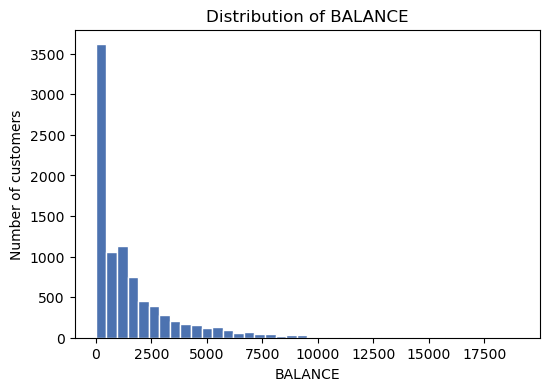

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["BALANCE"].dropna(), bins=40, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of BALANCE")
ax.set_xlabel("BALANCE")
ax.set_ylabel("Number of customers")
plt.show()


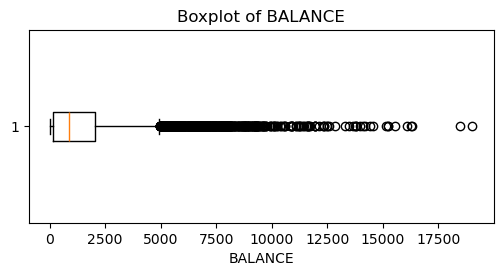

In [25]:
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.boxplot(df["BALANCE"].dropna(), vert=False)
ax.set_title("Boxplot of BALANCE")
ax.set_xlabel("BALANCE")
plt.show()


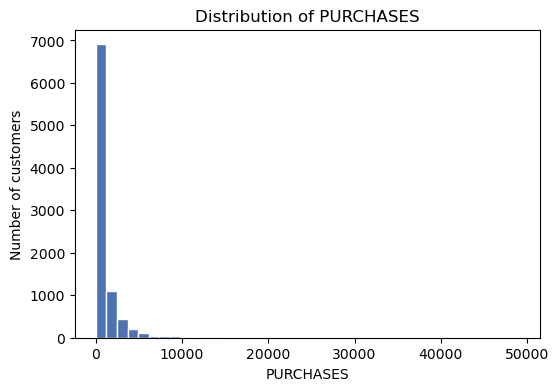

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["PURCHASES"].dropna(), bins=40, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of PURCHASES")
ax.set_xlabel("PURCHASES")
ax.set_ylabel("Number of customers")
plt.show()


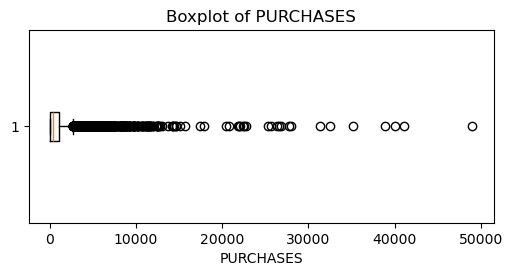

In [27]:
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.boxplot(df["PURCHASES"].dropna(), vert=False)
ax.set_title("Boxplot of PURCHASES")
ax.set_xlabel("PURCHASES")
plt.show()


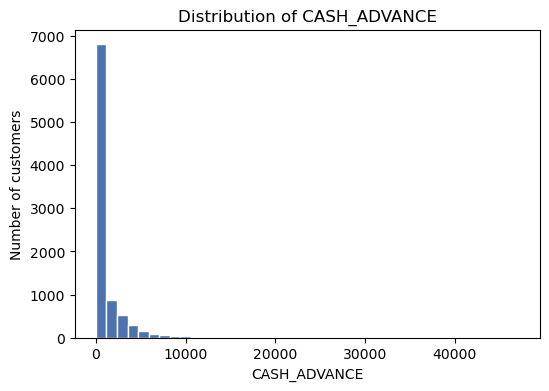

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["CASH_ADVANCE"].dropna(), bins=40, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of CASH_ADVANCE")
ax.set_xlabel("CASH_ADVANCE")
ax.set_ylabel("Number of customers")
plt.show()


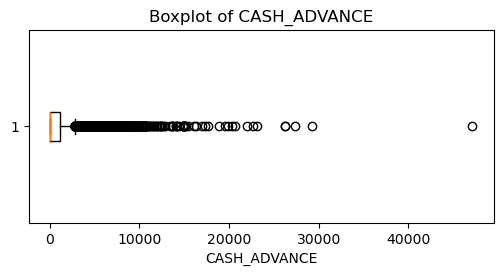

In [29]:
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.boxplot(df["CASH_ADVANCE"].dropna(), vert=False)
ax.set_title("Boxplot of CASH_ADVANCE")
ax.set_xlabel("CASH_ADVANCE")
plt.show()


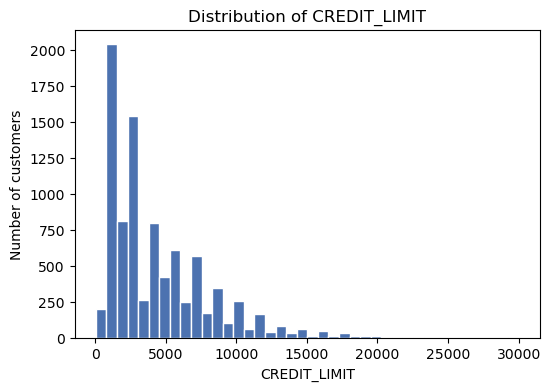

In [30]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["CREDIT_LIMIT"].dropna(), bins=40, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of CREDIT_LIMIT")
ax.set_xlabel("CREDIT_LIMIT")
ax.set_ylabel("Number of customers")
plt.show()


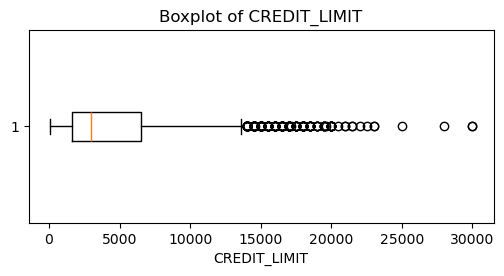

In [31]:
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.boxplot(df["CREDIT_LIMIT"].dropna(), vert=False)
ax.set_title("Boxplot of CREDIT_LIMIT")
ax.set_xlabel("CREDIT_LIMIT")
plt.show()


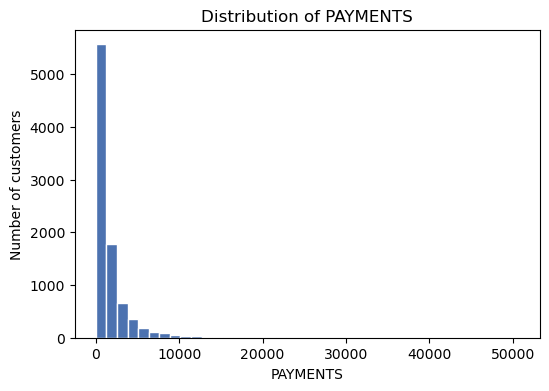

In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["PAYMENTS"].dropna(), bins=40, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of PAYMENTS")
ax.set_xlabel("PAYMENTS")
ax.set_ylabel("Number of customers")
plt.show()


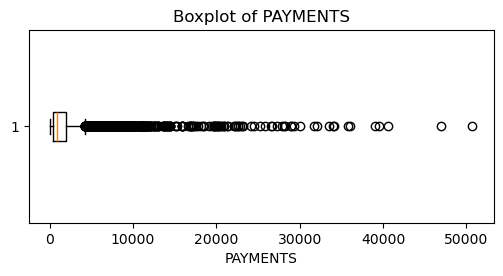

In [33]:
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.boxplot(df["PAYMENTS"].dropna(), vert=False)
ax.set_title("Boxplot of PAYMENTS")
ax.set_xlabel("PAYMENTS")
plt.show()


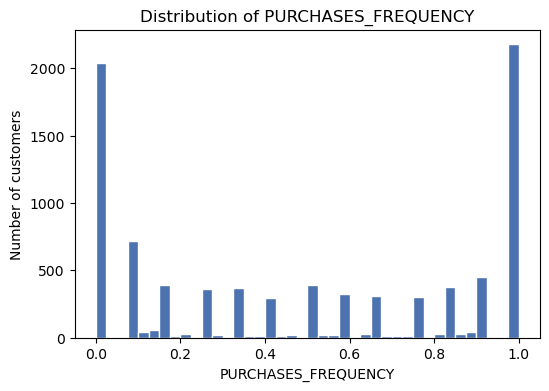

In [34]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["PURCHASES_FREQUENCY"].dropna(), bins=40, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of PURCHASES_FREQUENCY")
ax.set_xlabel("PURCHASES_FREQUENCY")
ax.set_ylabel("Number of customers")
plt.show()


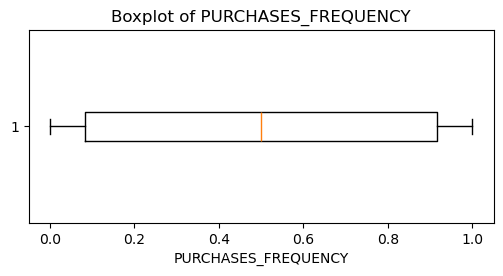

In [35]:
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.boxplot(df["PURCHASES_FREQUENCY"].dropna(), vert=False)
ax.set_title("Boxplot of PURCHASES_FREQUENCY")
ax.set_xlabel("PURCHASES_FREQUENCY")
plt.show()


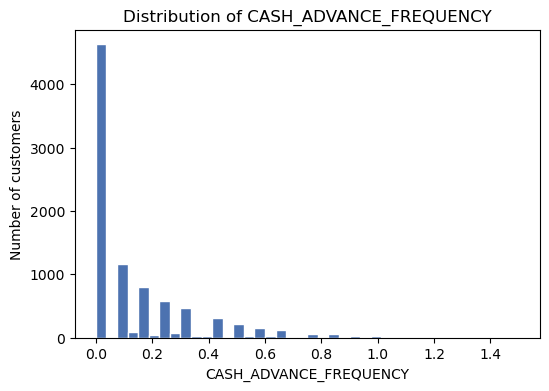

In [36]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["CASH_ADVANCE_FREQUENCY"].dropna(), bins=40, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of CASH_ADVANCE_FREQUENCY")
ax.set_xlabel("CASH_ADVANCE_FREQUENCY")
ax.set_ylabel("Number of customers")
plt.show()


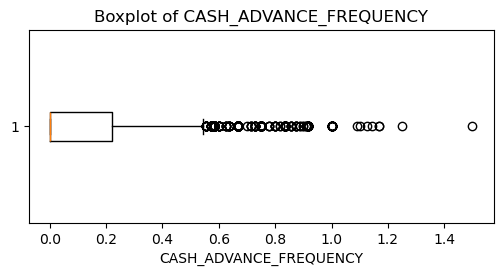

In [37]:
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.boxplot(df["CASH_ADVANCE_FREQUENCY"].dropna(), vert=False)
ax.set_title("Boxplot of CASH_ADVANCE_FREQUENCY")
ax.set_xlabel("CASH_ADVANCE_FREQUENCY")
plt.show()


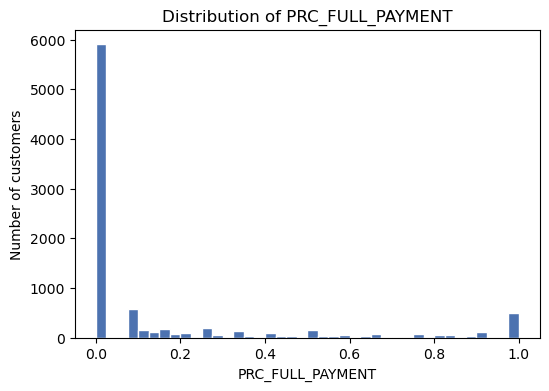

In [38]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["PRC_FULL_PAYMENT"].dropna(), bins=40, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of PRC_FULL_PAYMENT")
ax.set_xlabel("PRC_FULL_PAYMENT")
ax.set_ylabel("Number of customers")
plt.show()


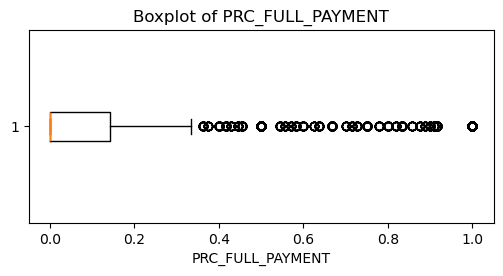

In [39]:
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.boxplot(df["PRC_FULL_PAYMENT"].dropna(), vert=False)
ax.set_title("Boxplot of PRC_FULL_PAYMENT")
ax.set_xlabel("PRC_FULL_PAYMENT")
plt.show()


### Interpretation

The skewness table confirms what the histograms show:

- **`PURCHASES`** (skewness ≈ 8.14), **`PAYMENTS`** (≈ 5.91), and **`CASH_ADVANCE`** (≈ 5.17) are **strongly right-skewed**. Their histograms show a tall bar near zero and a long, thin tail extending toward very large values, and their boxplots show many points above the upper whisker.
- **`BALANCE`** (≈ 2.39) and **`CREDIT_LIMIT`** (≈ 1.52) are also right-skewed, though less extremely than the spending-related variables.
- **`CASH_ADVANCE_FREQUENCY`** (≈ 1.83) and **`PRC_FULL_PAYMENT`** (≈ 1.94) are right-skewed as well, which matches the fact that most customers score close to 0 on both variables (most customers rarely use cash advances and rarely pay in full).
- **`PURCHASES_FREQUENCY`** (≈ 0.06) is close to symmetric, confirming the earlier observation that its mean and median are almost equal.

None of these variables looks approximately normal, so **no statistical test in this project should assume normality for these raw variables** without checking it first. The right-skewness is also a practical reason (in addition to the difference in scale) why we will standardize the variables before clustering in Section 11: K-means uses Euclidean distance, which is sensitive to both scale and to a few very extreme values.

## 5. Relationship Analysis

### Question / Goal
How are pairs of customer-behavior variables related to each other?

### Method
We build scatterplots for five relationships that are directly useful for understanding customer behavior. We describe these relationships using neutral, associative language ("is associated with"), never causal language ("causes"), since this is observational data.

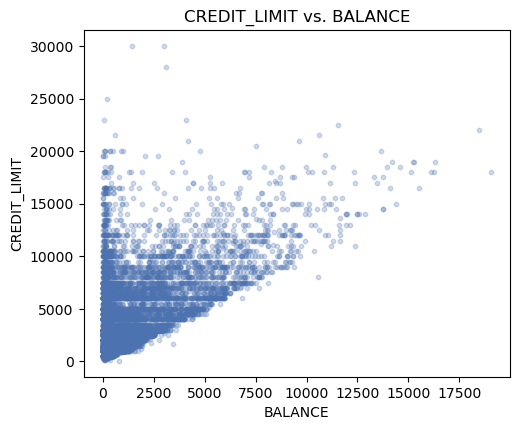

Correlation between BALANCE and CREDIT_LIMIT: 0.531


In [41]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(df["BALANCE"], df["CREDIT_LIMIT"], alpha=0.25, s=10, color="#4C72B0")
ax.set_xlabel("BALANCE")
ax.set_ylabel("CREDIT_LIMIT")
ax.set_title("CREDIT_LIMIT vs. BALANCE")
plt.show()
r = df[["BALANCE", "CREDIT_LIMIT"]].corr().iloc[0, 1]
print(f"Correlation between BALANCE and CREDIT_LIMIT: {r:.3f}")


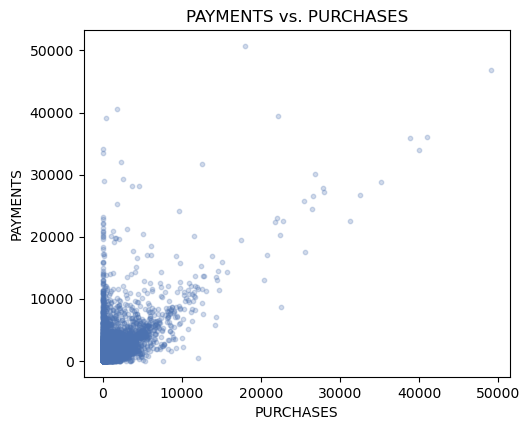

Correlation between PURCHASES and PAYMENTS: 0.603


In [42]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(df["PURCHASES"], df["PAYMENTS"], alpha=0.25, s=10, color="#4C72B0")
ax.set_xlabel("PURCHASES")
ax.set_ylabel("PAYMENTS")
ax.set_title("PAYMENTS vs. PURCHASES")
plt.show()
r = df[["PURCHASES", "PAYMENTS"]].corr().iloc[0, 1]
print(f"Correlation between PURCHASES and PAYMENTS: {r:.3f}")


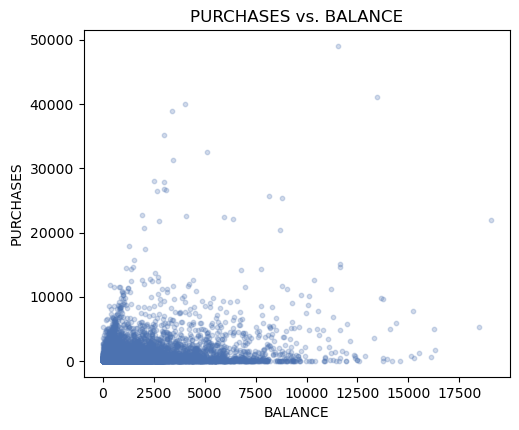

Correlation between BALANCE and PURCHASES: 0.181


In [43]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(df["BALANCE"], df["PURCHASES"], alpha=0.25, s=10, color="#4C72B0")
ax.set_xlabel("BALANCE")
ax.set_ylabel("PURCHASES")
ax.set_title("PURCHASES vs. BALANCE")
plt.show()
r = df[["BALANCE", "PURCHASES"]].corr().iloc[0, 1]
print(f"Correlation between BALANCE and PURCHASES: {r:.3f}")


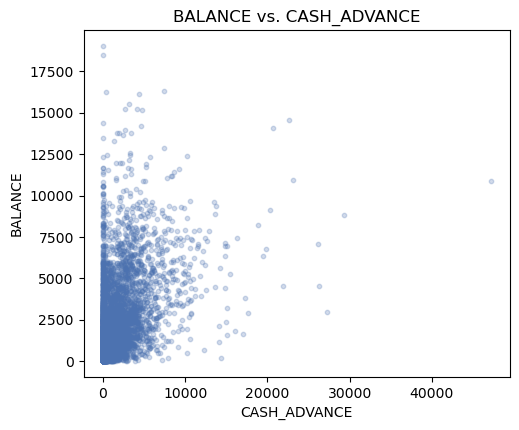

Correlation between CASH_ADVANCE and BALANCE: 0.497


In [44]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(df["CASH_ADVANCE"], df["BALANCE"], alpha=0.25, s=10, color="#4C72B0")
ax.set_xlabel("CASH_ADVANCE")
ax.set_ylabel("BALANCE")
ax.set_title("BALANCE vs. CASH_ADVANCE")
plt.show()
r = df[["CASH_ADVANCE", "BALANCE"]].corr().iloc[0, 1]
print(f"Correlation between CASH_ADVANCE and BALANCE: {r:.3f}")


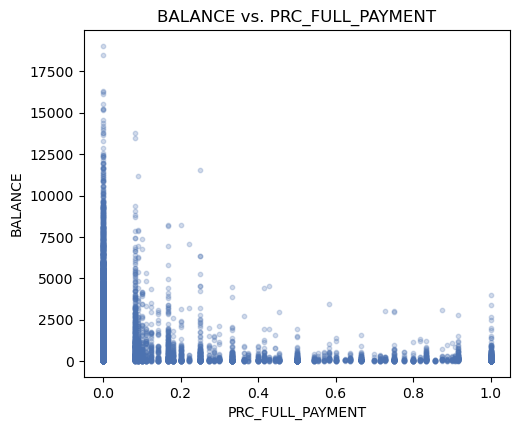

Correlation between PRC_FULL_PAYMENT and BALANCE: -0.319


In [45]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(df["PRC_FULL_PAYMENT"], df["BALANCE"], alpha=0.25, s=10, color="#4C72B0")
ax.set_xlabel("PRC_FULL_PAYMENT")
ax.set_ylabel("BALANCE")
ax.set_title("BALANCE vs. PRC_FULL_PAYMENT")
plt.show()
r = df[["PRC_FULL_PAYMENT", "BALANCE"]].corr().iloc[0, 1]
print(f"Correlation between PRC_FULL_PAYMENT and BALANCE: {r:.3f}")


### Interpretation

- **`BALANCE` vs. `CREDIT_LIMIT`** (r ≈ 0.53): a moderate positive association — banks tend to give higher credit limits to customers who also carry higher balances, which is expected since credit limits are typically set based on a customer's credit profile.
- **`PURCHASES` vs. `PAYMENTS`** (r ≈ 0.60): a moderate-to-strong positive association — customers who purchase more also tend to pay more, which makes sense since larger purchase volumes generate larger repayment amounts.
- **`BALANCE` vs. `PURCHASES`** (r ≈ 0.18): a weak positive association — carrying a high balance is only weakly related to how much a customer purchases, suggesting that balance is driven by more than just recent purchase volume (e.g., cash advances or revolving debt).
- **`CASH_ADVANCE` vs. `BALANCE`** (r ≈ 0.50): a moderate positive association — customers who use more cash advances tend to carry higher balances, consistent with cash advances contributing to outstanding debt.
- **`PRC_FULL_PAYMENT` vs. `BALANCE`** (r ≈ -0.32): a moderate negative association — customers who pay a larger share of their balance in full tend to carry lower balances, which is intuitive: fully paying off debt regularly prevents balances from accumulating.

None of these associations imply causation; they simply describe how these variables move together in this sample of customers.

## 6. Correlation Analysis

### Question / Goal
Which variables are strongly related to each other, and could this create redundancy if we used all of them for clustering?

### Method
We build a correlation matrix for a broader set of numerical variables (including the components of `PURCHASES` and `CASH_ADVANCE`) and visualize it as a heatmap built directly with matplotlib.

In [46]:
corr_vars = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
             "CASH_ADVANCE", "CASH_ADVANCE_FREQUENCY", "CASH_ADVANCE_TRX",
             "CREDIT_LIMIT", "PAYMENTS", "PURCHASES_FREQUENCY", "PRC_FULL_PAYMENT"]

corr_matrix = df[corr_vars].corr()
corr_matrix.round(2)


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,PURCHASES_FREQUENCY,PRC_FULL_PAYMENT
BALANCE,1.00,0.18,0.16,0.13,0.50,0.45,0.39,0.53,0.32,-0.08,-0.32
PURCHASES,0.18,1.00,0.92,0.68,-0.05,-0.12,-0.07,0.36,0.60,0.39,0.18
ONEOFF_PURCHASES,0.16,0.92,1.00,0.33,-0.03,-0.08,-0.05,0.32,0.57,0.26,0.13
INSTALLMENTS_PURCHASES,0.13,0.68,0.33,1.00,-0.06,-0.13,-0.07,0.26,0.38,0.44,0.18
CASH_ADVANCE,0.50,-0.05,-0.03,-0.06,1.00,0.63,0.66,0.30,0.45,-0.22,-0.15
CASH_ADVANCE_FREQUENCY,0.45,-0.12,-0.08,-0.13,0.63,1.00,0.80,0.13,0.18,-0.31,-0.25
CASH_ADVANCE_TRX,0.39,-0.07,-0.05,-0.07,0.66,0.80,1.00,0.15,0.26,-0.20,-0.17
CREDIT_LIMIT,0.53,0.36,0.32,0.26,0.30,0.13,0.15,1.00,0.42,0.12,0.06
PAYMENTS,0.32,0.60,0.57,0.38,0.45,0.18,0.26,0.42,1.00,0.10,0.11
PURCHASES_FREQUENCY,-0.08,0.39,0.26,0.44,-0.22,-0.31,-0.20,0.12,0.10,1.00,0.31


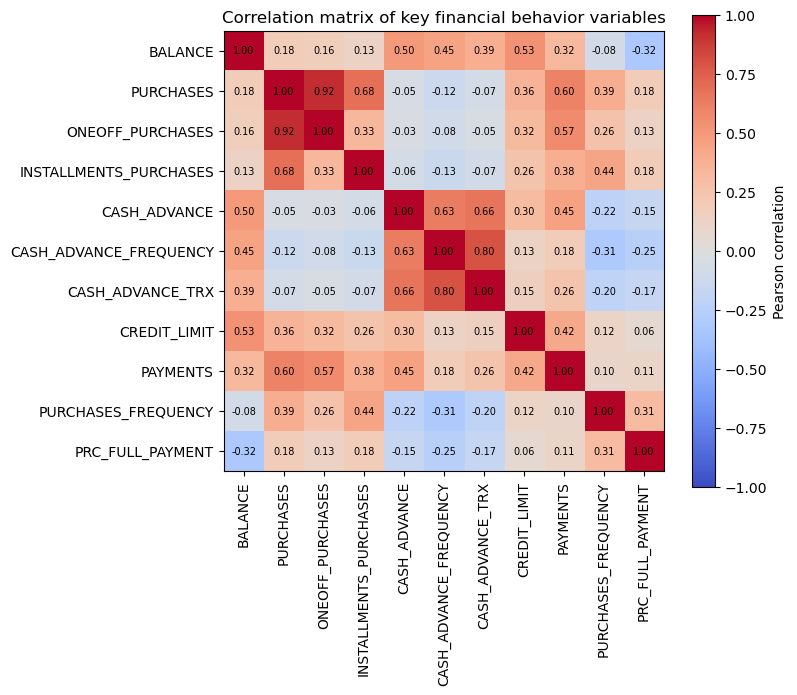

In [47]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_vars)))
ax.set_xticklabels(corr_vars, rotation=90)
ax.set_yticks(range(len(corr_vars)))
ax.set_yticklabels(corr_vars)

for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Correlation matrix of key financial behavior variables")
plt.tight_layout()
plt.show()


### Interpretation

Two groups of variables show clear redundancy:

- **`PURCHASES`, `ONEOFF_PURCHASES`, and `INSTALLMENTS_PURCHASES`**: `PURCHASES` correlates very strongly with `ONEOFF_PURCHASES` (r ≈ 0.92) and strongly with `INSTALLMENTS_PURCHASES` (r ≈ 0.68). This makes sense, because `PURCHASES` is essentially the sum of the other two. Using all three in clustering would let "total purchase volume" dominate the distance calculation twice.
- **`CASH_ADVANCE`, `CASH_ADVANCE_FREQUENCY`, and `CASH_ADVANCE_TRX`**: `CASH_ADVANCE_FREQUENCY` and `CASH_ADVANCE_TRX` are very strongly correlated (r ≈ 0.80), and both are moderately-to-strongly correlated with `CASH_ADVANCE` (r ≈ 0.63 and 0.66). These three variables largely describe the same underlying behavior (how much a customer relies on cash advances) from slightly different angles.

Other relationships are moderate: `CREDIT_LIMIT` correlates moderately with `BALANCE` (r ≈ 0.53) and `PAYMENTS` (r ≈ 0.42). Most correlations involving `PURCHASES_FREQUENCY` and `PRC_FULL_PAYMENT` with the spending/cash-advance variables are weak (|r| below roughly 0.3), meaning these two "behavioral habit" variables carry information that is not already captured by the dollar-amount variables.

This redundancy analysis directly motivates the variable-selection decisions made in Section 9: we avoid including near-duplicate variables (like `PURCHASES` together with both of its components) in the clustering step.

## 7. EDA Conclusions

The exploratory analysis shows that the 8,950 customers in this dataset are **far from homogeneous**:

- **Balances** range from 0 to over 19,000, with most customers holding relatively low balances but a meaningful subset carrying much higher ones (right-skewed distribution).
- **Purchase behavior** is highly uneven: many customers purchase very little, while a small group purchases tens of thousands of dollars' worth of goods (extreme right skew, skewness ≈ 8.1).
- **Cash-advance behavior** is concentrated at zero for the majority of customers (median = 0), but a distinct subgroup relies heavily on cash advances, reaching values in the tens of thousands.
- **Payments and credit limits** also vary widely across customers, and are moderately correlated with balance and purchase activity.
- **Payment habits** (`PRC_FULL_PAYMENT`) show that most customers rarely pay their balance in full, while a smaller group does so consistently.

In short, customers differ substantially across several independent dimensions of financial behavior at the same time (how much they spend, how they finance it, and how they repay it). No single variable, and no single hypothesis test between two groups, can fully describe this multidimensional heterogeneity. This naturally motivates looking for **groups of customers who share similar combinations of behaviors**, which is the goal of the clustering analysis in the next section.

## 8. Statistical Motivation for Clustering

The EDA above shows that customers vary simultaneously across several dimensions of financial behavior: balance, purchasing, cash-advance use, credit capacity, and repayment habits. The dataset does **not** come with predefined customer categories (there is no "customer type" column) — any segmentation has to be discovered from the data itself.

**K-means clustering** is an *unsupervised* statistical technique: unlike the hypothesis tests and regression models covered in this course, it does not test a pre-specified hypothesis about a known grouping variable. Instead, it searches for groups of customers who are similar to each other (and different from customers in other groups) across several numerical variables at once, purely based on the numbers.

For this project, clustering is used as an **exploratory extension** of the statistical analysis:

- It does **not** replace the confidence intervals, hypothesis tests, correlation analysis, or regression performed elsewhere in the project.
- It is a complementary, descriptive tool that helps answer a different question: *"Do customers naturally fall into a small number of recognizable behavioral profiles?"*
- The resulting clusters are best understood as **exploratory customer profiles**, useful for description and further investigation, rather than as a definitive classification of "true" customer types.

## 9. Initial Feature Selection for Clustering

We do not use all 17 numerical variables in the clustering step. Based on the correlation analysis in Section 6, several variables (like `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES`, `CASH_ADVANCE_TRX`) are strongly correlated with a broader variable that already summarizes the same behavior. Including both would let that behavior count twice in the distance calculation and would make the resulting clusters harder to interpret.

We start with eight variables that together describe distinct aspects of customer financial behavior without excessive redundancy:

| Variable | What it represents |
|---|---|
| `BALANCE` | The customer's outstanding credit card balance |
| `PURCHASES` | Total purchasing activity (already summarizes one-off and installment purchases) |
| `CASH_ADVANCE` | Total use of cash advances (dollar amount) |
| `CREDIT_LIMIT` | Available credit capacity granted to the customer |
| `PAYMENTS` | Total repayment activity |
| `PURCHASES_FREQUENCY` | How regularly the customer makes purchases |
| `CASH_ADVANCE_FREQUENCY` | How regularly the customer uses cash advances |
| `PRC_FULL_PAYMENT` | How often the customer pays the full balance |

We keep both `CASH_ADVANCE` (amount) and `CASH_ADVANCE_FREQUENCY` (regularity) because, although moderately correlated (r ≈ 0.63, Section 6), they still capture two different questions: *how much* a customer borrows through cash advances versus *how often* they do so — a customer could take one very large cash advance (high amount, low frequency) or many small ones (lower amount, high frequency), and we want the clustering to be able to tell these apart. We exclude `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES`, and `CASH_ADVANCE_TRX` specifically because they are near-duplicates of variables already in the list.

## 10. Missing Values for Clustering

### Question / Goal
Do the selected clustering variables have missing values, and if so, how should we handle them?

### Method
We build a clustering-specific data frame containing only the eight selected variables (plus `CUST_ID` for reference) and check missing values only within this subset.

In [48]:
cluster_vars = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS",
                "PURCHASES_FREQUENCY", "CASH_ADVANCE_FREQUENCY", "PRC_FULL_PAYMENT"]

n_before = len(df)
cluster_df = df.dropna(subset=cluster_vars).copy()
n_after = len(cluster_df)

print("Observations before cleaning:", n_before)
print("Observations after cleaning:", n_after)
print("Observations removed:", n_before - n_after)
print("Percentage removed: {:.3f}%".format((n_before - n_after) / n_before * 100))


Observations before cleaning: 8950
Observations after cleaning: 8949
Observations removed: 1
Percentage removed: 0.011%


### Interpretation

Only **one row** (the single missing value in `CREDIT_LIMIT` identified in Section 2) is removed — about 0.01% of the dataset. Because this affects such a tiny fraction of customers, and there is no reasonable way to guess a customer's true credit limit from the other variables without introducing bias, removing this single row is a reasonable and low-impact decision. No other rows are affected, since `MINIMUM_PAYMENTS` (the variable with more missing values) is not part of the clustering variable set.

## 11. Standardization

### Question / Goal
Why is it necessary to standardize the clustering variables before running K-means?

### Method
K-means groups customers based on **Euclidean distance** between their variable values. If variables are left in their original units, variables with naturally larger numbers will dominate the distance calculation. For example, `CREDIT_LIMIT`, `PURCHASES`, and `BALANCE` can be in the thousands, while `PURCHASES_FREQUENCY` and `PRC_FULL_PAYMENT` only range between 0 and 1. Without standardization, a difference of 500 in `CREDIT_LIMIT` would count far more than an equally meaningful difference of 0.5 in `PURCHASES_FREQUENCY`.

We standardize every clustering variable to a mean of 0 and a standard deviation of 1 using the z-score transformation:

$$z = \frac{x - \bar{x}}{s}$$

where $x$ is the original value, $\bar{x}$ is the variable's mean, and $s$ is its standard deviation. After this transformation, each variable contributes to the distance calculation on a comparable scale.

In [49]:
X = cluster_df[cluster_vars].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_check = pd.DataFrame(X_scaled, columns=cluster_vars)
print("Mean of each standardized variable (should be ~0):")
print(scaled_check.mean().round(4))
print()
print("Standard deviation of each standardized variable (should be ~1):")
print(scaled_check.std().round(4))


Mean of each standardized variable (should be ~0):
BALANCE                   0.0
PURCHASES                -0.0
CASH_ADVANCE             -0.0
CREDIT_LIMIT              0.0
PAYMENTS                  0.0
PURCHASES_FREQUENCY       0.0
CASH_ADVANCE_FREQUENCY   -0.0
PRC_FULL_PAYMENT         -0.0
dtype: float64

Standard deviation of each standardized variable (should be ~1):
BALANCE                   1.0001
PURCHASES                 1.0001
CASH_ADVANCE              1.0001
CREDIT_LIMIT              1.0001
PAYMENTS                  1.0001
PURCHASES_FREQUENCY       1.0001
CASH_ADVANCE_FREQUENCY    1.0001
PRC_FULL_PAYMENT          1.0001
dtype: float64


### Interpretation

After standardization, every variable has a mean of approximately 0 and a standard deviation of approximately 1, confirming that all eight variables are now expressed on a comparable scale. This is the array (`X_scaled`) that will be used for the K-means algorithm from this point forward. The cluster interpretation later, however, will use the **original, unscaled units** (dollars and proportions), since standardized z-scores are not meaningful to a non-technical reader.

## 12. Choosing the Number of Clusters

### Question / Goal
How many clusters (K) should we use? We do not simply assume K = 4; we evaluate a range of values and justify the final choice.

### Method
For each value of K from 2 to 10, we run K-means and record two quantities:

- **Inertia** (within-cluster sum of squares): a measure of how tightly grouped the observations are within each cluster. It always decreases as K increases, so we look for the point where it stops decreasing quickly — this is the **Elbow Method**.
- **Silhouette score**: measures, for each observation, how much closer it is to its own cluster than to the nearest neighboring cluster, averaged across all observations. Values range from -1 to 1; higher values indicate better-separated clusters — this is the **Silhouette Method**.

We do not automatically pick the K with the single highest silhouette score, because the very best silhouette score is often obtained with a very small number of clusters (e.g., K = 2), which may be statistically "clean" but not useful for describing customer behavior in enough detail. Instead, we combine both metrics with a judgment about interpretability.

In [52]:
K_range = range(2, 6)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=123, n_init=25)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=3000, random_state=123)
    sil_scores.append(sil)

k_results = pd.DataFrame({
    "K": list(K_range),
    "inertia": [round(v, 1) for v in inertias],
    "silhouette_score": [round(v, 4) for v in sil_scores]
}).set_index("K")
k_results


,inertia,silhouette_score
K,,
2,56013.9,0.3866
3,46886.3,0.2356
4,40925.7,0.2417
5,35202.5,0.2634


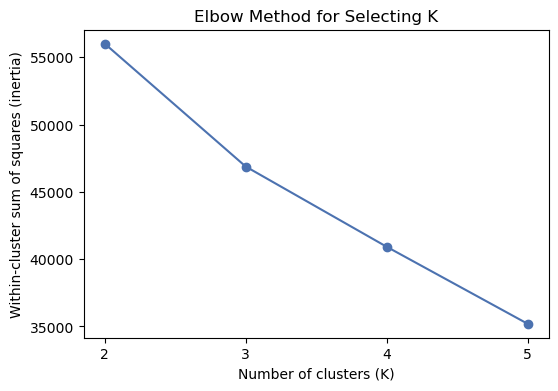

In [53]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(K_range), inertias, marker="o", color="#4C72B0")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Within-cluster sum of squares (inertia)")
ax.set_title("Elbow Method for Selecting K")
ax.set_xticks(list(K_range))
plt.show()


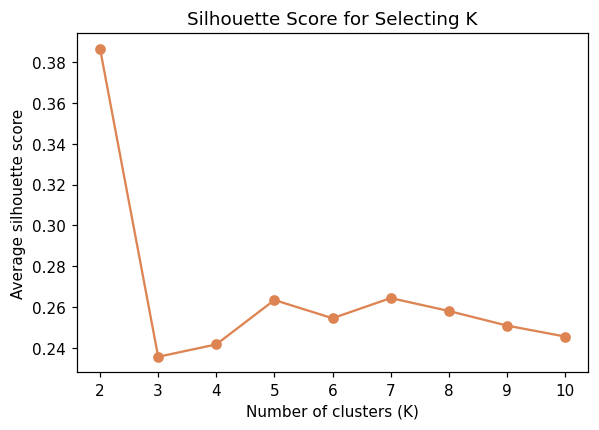

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(K_range), sil_scores, marker="o", color="#DD8452")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Average silhouette score")
ax.set_title("Silhouette Score for Selecting K")
ax.set_xticks(list(K_range))
plt.show()


### Interpretation and choice of K

**Elbow Method:** inertia drops quickly from K = 2 to K = 5 (from about 56,000 to about 35,200), and the size of each additional drop becomes clearly smaller from K = 5 onward (the improvement from K = 5 to K = 6 is much smaller than from K = 4 to K = 5). This is the "elbow" region — adding more clusters after this point gives diminishing returns.

**Silhouette Method:** the highest silhouette score occurs at K = 2 (≈ 0.39), which is expected — with only two groups, clusters are naturally far apart, but this is too coarse to describe meaningfully different financial profiles. Beyond K = 2, the silhouette score is fairly flat (roughly between 0.24 and 0.26), with small local peaks at K = 5 (≈ 0.263) and K = 7 (≈ 0.264).

**Final decision — K = 5.** We select K = 5 rather than the elbow's raw minimum-improvement point or the silhouette's global maximum, because:

1. K = 5 sits right where the elbow curve's rate of improvement starts to flatten out.
2. K = 5 has one of the two local silhouette peaks after the trivial K = 2 solution, meaning its cluster separation is reasonably good relative to nearby values of K.
3. As we will see in Section 15, K = 5 produces clusters that are each large enough to be meaningful and clearly distinguishable in terms of balance, spending, cash-advance use, and payment behavior — including one small but distinct group of customers who consistently pay their balance in full, a pattern that gets blended into other groups at smaller values of K.

K = 5 is therefore chosen as a reasonable balance between statistical support (elbow and silhouette) and interpretability, not as an arbitrary default.

## 13. K-Means Clustering

### Method
We run K-means with the selected value, K = 5, using `random_state = 123` for reproducibility and `n_init = 25`. K-means starts from randomly chosen initial cluster centers, and a poor random starting point can lead to a poor final solution (a "local optimum"). Using `n_init = 25` runs the algorithm 25 times from different random starting points and automatically keeps the best solution (the one with the lowest inertia), which greatly reduces the risk of reporting a suboptimal clustering result.

In [54]:
best_k = 5

kmeans_final = KMeans(n_clusters=best_k, random_state=123, n_init=25)
cluster_labels = kmeans_final.fit_predict(X_scaled)

cluster_df["Cluster"] = cluster_labels

print("Final K used:", best_k)
print()
print("Number of customers per cluster:")
print(cluster_df["Cluster"].value_counts().sort_index())


Final K used: 5

Number of customers per cluster:
Cluster
0    3561
1    2887
2     112
3    1274
4    1115
Name: count, dtype: int64


We do not interpret these numbers yet — we first attach the cluster labels to the original, unscaled data and build a full cluster profile in the next section.

## 14. Add Clusters Back to the Original Data

The cluster labels were computed on the **standardized** variables (`X_scaled`), but standardized z-scores are not meaningful for a general reader. We therefore attach the cluster label to `cluster_df`, which still holds the clustering variables in their **original units** (dollars for monetary variables, proportions for frequency variables). All cluster summaries and interpretations from this point onward use these original units.

In [55]:
cluster_df[["CUST_ID"] + cluster_vars + ["Cluster"]].head()


,CUST_ID,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,Cluster
0,C10001,40.900749,95.40,0.000000,1000.0,201.802084,0.166667,0.000000,0.000000,0
1,C10002,3202.467416,0.00,6442.945483,7000.0,4103.032597,0.000000,0.250000,0.222222,4
2,C10003,2495.148862,773.17,0.000000,7500.0,622.066742,1.000000,0.000000,0.000000,1
3,C10004,1666.670542,1499.00,205.788017,7500.0,0.000000,0.083333,0.083333,0.000000,0
4,C10005,817.714335,16.00,0.000000,1200.0,678.334763,0.083333,0.000000,0.000000,0


## 15. Cluster Profile Table

### Method
For every cluster, we compute the number and percentage of customers, plus the mean and median of each clustering variable in original units.

In [56]:
cluster_sizes = cluster_df["Cluster"].value_counts().sort_index()
cluster_pct = (cluster_sizes / len(cluster_df) * 100).round(1)

profile_mean = cluster_df.groupby("Cluster")[cluster_vars].mean().round(2)
profile_median = cluster_df.groupby("Cluster")[cluster_vars].median().round(2)

profile_mean.insert(0, "n_customers", cluster_sizes)
profile_mean.insert(1, "pct_of_total", cluster_pct)

print("Cluster profile - MEAN values (original units):")
profile_mean


Cluster profile - MEAN values (original units):


,n_customers,pct_of_total,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT
Cluster,,,,,,,,,,
0,3561,39.8,1117.49,205.85,734.90,2999.07,905.74,0.13,0.15,0.03
1,2887,32.3,1239.86,1381.76,240.48,4258.32,1419.55,0.85,0.05,0.06
2,112,1.3,4341.66,13545.21,1216.05,12405.36,15533.07,0.88,0.08,0.36
3,1274,14.2,143.81,1433.97,63.70,4880.58,1657.67,0.78,0.01,0.80
4,1115,12.5,5178.20,818.44,4692.48,8645.83,3889.20,0.35,0.45,0.03


In [57]:
print("Cluster profile - MEDIAN values (original units):")
profile_median


Cluster profile - MEDIAN values (original units):


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT
Cluster,,,,,,,,
0,935.04,45.65,267.00,2500.0,532.74,0.08,0.08,0.00
1,837.14,889.66,0.00,3000.0,950.74,0.92,0.00,0.00
2,3002.29,11167.98,0.00,12000.0,11920.13,1.00,0.00,0.17
3,79.21,806.46,0.00,4000.0,1007.64,0.92,0.00,0.83
4,4939.65,204.80,3932.27,8000.0,2234.91,0.17,0.42,0.00


## 16. Cluster Interpretation

Only now, after examining the actual cluster means and medians above, do we describe and name each cluster. The names are descriptive labels chosen to match the numbers, not the other way around.

**Cluster 0 — "Low-Activity Customers" (n = 3,561, 39.8% of customers).**
Low balance (mean ≈ \$1,117), very low purchases (mean ≈ \$206), low purchase frequency (0.13), moderate cash-advance use (mean ≈ \$735), and almost no full payments (0.03). This is the largest group: customers who use their card lightly overall, across almost every dimension.

**Cluster 1 — "Regular Purchasers with Low Cash-Advance Use" (n = 2,887, 32.3%).**
Moderate balance (≈ \$1,240), meaningful purchase activity (mean ≈ \$1,382) with high purchase frequency (0.85), but very low cash-advance amount (≈ \$240) and frequency (0.05). These customers use their card mainly for regular purchases rather than for borrowing cash.

**Cluster 2 — "High-Value / High-Spending Customers" (n = 112, 1.3%).**
By far the highest purchases (mean ≈ \$13,545), the highest credit limit (mean ≈ \$12,405), and the highest payments (mean ≈ \$15,533), with high purchase frequency (0.88) and a notably higher share of full payments (0.36) than most other clusters. This is a small but distinct group of high-value customers with substantial spending power.

**Cluster 3 — "Full-Payment, Low-Balance Customers" (n = 1,274, 14.2%).**
Very low balance (mean ≈ \$144) and very low cash-advance use (≈ \$64), combined with moderate purchases (≈ \$1,434) and by far the **highest share of full payments** (mean ≈ 0.80, median ≈ 0.83). These customers actively use their card for purchases but consistently pay off their balance, avoiding carried debt.

**Cluster 4 — "Cash-Advance-Dependent Customers" (n = 1,115, 12.5%).**
High balance (mean ≈ \$5,178) driven mainly by the highest cash-advance amount (mean ≈ \$4,692) and the highest cash-advance frequency (0.45), combined with relatively low purchases (≈ \$818) and almost no full payments (0.03). This group relies on cash advances rather than on purchases, and tends to carry higher revolving balances.

Across all five clusters, the variables originally selected in Section 9 (balance, spending amount, cash-advance amount and frequency, credit limit, payments, and full-payment behavior) each contribute to distinguishing at least one cluster from the others, which supports the variable-selection decisions made earlier.

## 17. Visual Comparison of Cluster Profiles

To make the differences between clusters easier to see, we plot the mean of a few key variables by cluster, using original units. We limit this to the variables that most clearly distinguish the clusters, rather than plotting every variable.

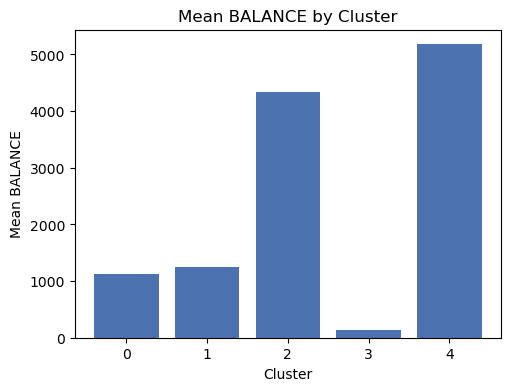

In [58]:
fig, ax = plt.subplots(figsize=(5.5, 4))
means = cluster_df.groupby("Cluster")["BALANCE"].mean()
ax.bar(means.index.astype(str), means.values, color="#4C72B0")
ax.set_xlabel("Cluster")
ax.set_ylabel("Mean BALANCE")
ax.set_title("Mean BALANCE by Cluster")
plt.show()


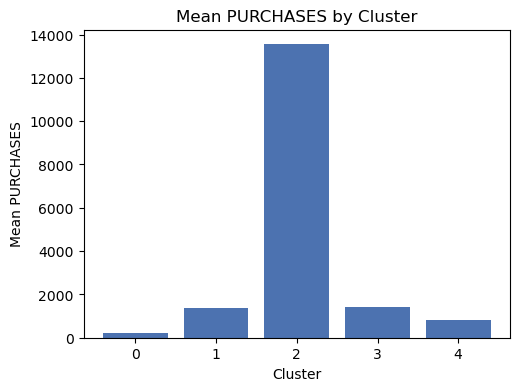

In [59]:
fig, ax = plt.subplots(figsize=(5.5, 4))
means = cluster_df.groupby("Cluster")["PURCHASES"].mean()
ax.bar(means.index.astype(str), means.values, color="#4C72B0")
ax.set_xlabel("Cluster")
ax.set_ylabel("Mean PURCHASES")
ax.set_title("Mean PURCHASES by Cluster")
plt.show()


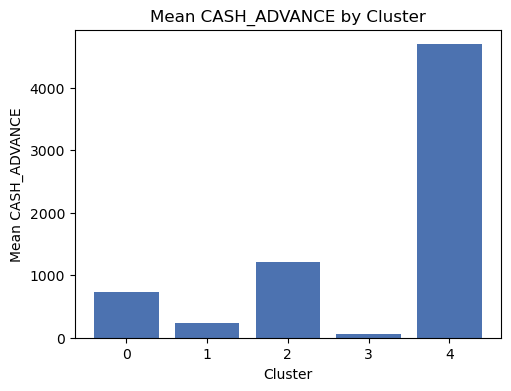

In [60]:
fig, ax = plt.subplots(figsize=(5.5, 4))
means = cluster_df.groupby("Cluster")["CASH_ADVANCE"].mean()
ax.bar(means.index.astype(str), means.values, color="#4C72B0")
ax.set_xlabel("Cluster")
ax.set_ylabel("Mean CASH_ADVANCE")
ax.set_title("Mean CASH_ADVANCE by Cluster")
plt.show()


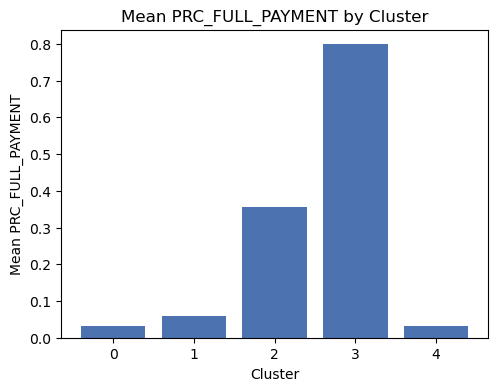

In [61]:
fig, ax = plt.subplots(figsize=(5.5, 4))
means = cluster_df.groupby("Cluster")["PRC_FULL_PAYMENT"].mean()
ax.bar(means.index.astype(str), means.values, color="#4C72B0")
ax.set_xlabel("Cluster")
ax.set_ylabel("Mean PRC_FULL_PAYMENT")
ax.set_title("Mean PRC_FULL_PAYMENT by Cluster")
plt.show()


### Interpretation

These charts visually confirm the profile table: Cluster 2 stands out with by far the highest average purchases; Cluster 4 stands out with by far the highest average cash-advance use; and Cluster 3 stands out with a much higher share of full payments than any other cluster, while carrying the lowest average balance. Clusters 0 and 1 are comparatively unremarkable on these specific variables, which is consistent with them representing "low activity" and "regular purchasing" behavior rather than an extreme pattern.

## 18. PCA for Cluster Visualization

### Method
The clustering itself uses eight dimensions, which cannot be plotted directly. **Principal Component Analysis (PCA) is used here only to project the multidimensional clustering solution into two dimensions for visualization** — it is not part of the clustering analysis itself, and the cluster assignments in Sections 15–17 do not depend on PCA in any way.

In [62]:
pca = PCA(n_components=2, random_state=123)
pcs = pca.fit_transform(X_scaled)

cluster_df["PC1"] = pcs[:, 0]
cluster_df["PC2"] = pcs[:, 1]

var_pc1, var_pc2 = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {var_pc1*100:.1f}%")
print(f"Variance explained by PC2: {var_pc2*100:.1f}%")
print(f"Variance explained by PC1 + PC2 combined: {(var_pc1+var_pc2)*100:.1f}%")


Variance explained by PC1: 34.1%
Variance explained by PC2: 26.2%
Variance explained by PC1 + PC2 combined: 60.4%


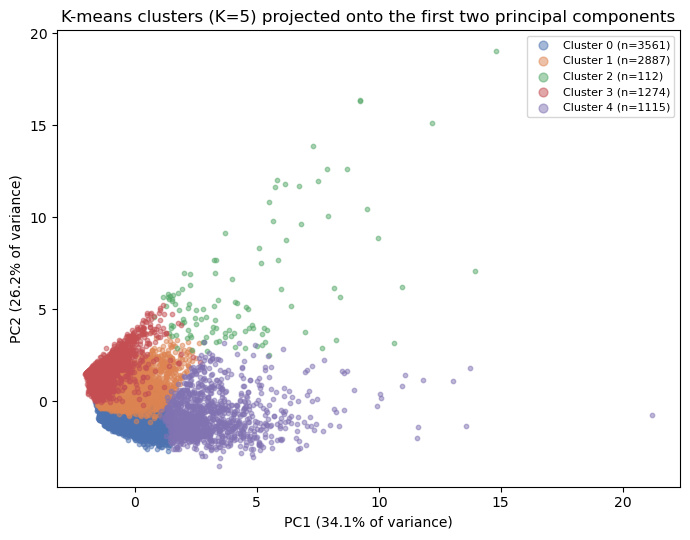

In [63]:
fig, ax = plt.subplots(figsize=(7, 5.5))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
for c in sorted(cluster_df["Cluster"].unique()):
    sub = cluster_df[cluster_df["Cluster"] == c]
    ax.scatter(sub["PC1"], sub["PC2"], s=10, alpha=0.5, color=colors[c],
               label=f"Cluster {c} (n={len(sub)})")
ax.set_xlabel(f"PC1 ({var_pc1*100:.1f}% of variance)")
ax.set_ylabel(f"PC2 ({var_pc2*100:.1f}% of variance)")
ax.set_title("K-means clusters (K=5) projected onto the first two principal components")
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()


### Interpretation

PC1 and PC2 together explain about 60.4% of the total variance in the eight standardized clustering variables. This means the 2D plot above is a useful **approximate** picture of the clustering solution, but it does not capture all the information used by K-means — roughly 40% of the variation between customers is not visible in this particular projection. Clusters 2 (high spenders) and 4 (cash-advance dependent) appear clearly separated from the rest in this projection, which is consistent with them being the most behaviorally distinct groups in the profile table. Clusters 0, 1, and 3 show more overlap in this 2D view, even though they are still distinguished by the algorithm using the full eight-dimensional space — a reminder that this chart is a visualization aid, not the full clustering result.

## 19. Cluster Quality and Limitations

This clustering analysis is a useful exploratory tool, but it has real limitations that should be kept in mind:

- **K-means assumes roughly compact, spherically shaped clusters** in the standardized variable space. If the true underlying groups have very different shapes or densities, K-means may not recover them accurately.
- **Results depend on the variables selected.** Choosing a different subset of the 17 available variables in Section 9 could produce a different segmentation. The eight variables used here were chosen for interpretability and to avoid redundancy, but they are not the only reasonable choice.
- **Results depend on standardization.** Using a different scaling method, or not standardizing at all, would change the distances between customers and could change the resulting clusters.
- **The selected K = 5 is not an absolute truth.** As shown in Section 12, several nearby values of K (4, 6, 7) are also statistically defensible; K = 5 was chosen as a reasonable balance between the elbow pattern, the silhouette score, and interpretability, not as the single "correct" answer.
- **Outliers can influence K-means**, since it is based on Euclidean distance and means. As discussed in Section 2, we deliberately did not remove outliers, since they may represent real (if unusual) customers; this is a reasonable choice for an exploratory analysis but means that a few extreme customers can pull a cluster's mean values upward.
- **Clusters describe patterns in this specific dataset; they do not create definitive, universal customer categories.** They should be read as exploratory customer profiles that summarize observed behavior, useful for further investigation rather than as a final classification system.

## 20. Final Conclusion

The exploratory data analysis showed that the 8,950 customers in this dataset are highly heterogeneous across several dimensions of financial behavior at once: balance, purchasing activity, cash-advance use, credit limits, and repayment habits are all right-skewed, with a minority of customers driving most of the extreme values. Because the dataset does not include predefined customer categories, and because this heterogeneity spans multiple variables simultaneously, K-means clustering was introduced as an **exploratory extension** of the statistical analysis, not as a replacement for it.

Eight variables — `BALANCE`, `PURCHASES`, `CASH_ADVANCE`, `CREDIT_LIMIT`, `PAYMENTS`, `PURCHASES_FREQUENCY`, `CASH_ADVANCE_FREQUENCY`, and `PRC_FULL_PAYMENT` — were selected based on their interpretability and on the correlation analysis, which showed that several other available variables were largely redundant with these eight. Because these variables are measured on very different scales (dollars in the thousands versus proportions between 0 and 1), they were standardized using z-scores before clustering, so that no single variable would dominate the distance calculation purely because of its scale.

The number of clusters was chosen by evaluating K from 2 to 10 using both the Elbow Method and the Silhouette Method, rather than assuming a fixed value. **K = 5** was selected as the point where the elbow curve's improvement clearly starts to flatten, where the silhouette score shows a local peak, and where the resulting clusters are large enough and distinct enough to interpret meaningfully.

The five resulting clusters describe recognizable, non-overlapping customer profiles: a large group of low-activity customers (39.8%), a large group of regular purchasers with little cash-advance use (32.3%), a small but distinct group of high-value, high-spending customers (1.3%), a group of customers who consistently pay their balance in full (14.2%), and a group of customers who depend heavily on cash advances and carry higher balances (12.5%).

This clustering analysis complements the rest of the statistics project: while hypothesis tests, correlation, and regression analyze relationships between specific pairs of variables or specific predefined groups, clustering describes how customers group together **across many variables simultaneously**, offering a complementary, descriptive view of customer heterogeneity that supports and enriches the other statistical findings rather than replacing them.